# Notebook 03 — Multi-Agent RL: Cooperação, Competição e Não-Estacionariedade

**Disciplina:** Modelos de Aprendizagem por Reforço  
**Aula:** 04 — Métodos Avançados em RL  
**Ambiente:** Stag Hunt (implementado do zero — sem PettingZoo)  
**Bibliotecas:** numpy, matplotlib

| | |
|---|---|
| **Aula** | Aula 04 — Métodos Avançados em Reinforcement Learning |
| **Notebook** | 03 — Multi-Agent RL (MARL) |
| **Seções** | 4.2 |
| **Tempo de leitura** | ~12 min |
| **Tempo de execução** | ~2 min |

**Pré-requisitos:** Notebook 02 desta aula (model-based RL); Q-Learning (Aula 02).

**Competências para o Desafio Final:** Identificar quando um problema requer MARL; compreender não-estacionariedade e CTDE; relacionar dinâmica de jogo a equilíbrios de Nash.

---

### Recapitulando

No Notebook 02, Dyna-Q demonstrou que um agente com modelo do ambiente converge mais rápido usando simulações internas. Esses métodos ainda assumem um **único agente**. Quando há múltiplos agentes aprendendo simultaneamente, o ambiente muda enquanto cada um aprende — violando a suposição de estacionariedade exigida pelo Q-Learning.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))

import rl_utils
rl_utils.info_versoes()
rl_utils.configurar_matplotlib()
rl_utils.definir_seeds(42)

Biblioteca           Versão
--------------------------------
gymnasium            1.0.0
torch                2.11.0+cu130
numpy                2.4.2
matplotlib           3.10.8
pandas               3.0.1
scikit-learn         1.8.0


## Bloco 1 — Contexto e pergunta central

Todo o RL das Aulas 02 e 03 pressupõe um único agente interagindo com um ambiente estacionário:
as regras não mudam, as recompensas não mudam, e ninguém mais está aprendendo ao mesmo tempo.

Quando há **vários agentes** aprendendo simultaneamente, essa suposição colapsa.
Do ponto de vista do Agente 1, o "ambiente" inclui o Agente 2 — que também está mudando
sua política a cada episódio. O que era ótimo ontem pode não ser ótimo hoje.

Isso é chamado de *non-stationarity* (não-estacionariedade): o ambiente muda porque
os outros agentes também aprendem.

> **Pergunta central:**  
> "O que acontece quando dois agentes treinados com Q-Learning independente precisam
> cooperar — e como a não-estacionariedade afeta o aprendizado?"

O *Multi-Agent Reinforcement Learning* — MARL (aprendizado por reforço multiagente) —
estuda exatamente esse problema.

## Bloco 2 — Mini teoria

### Tipos de interação multiagente

| Tipo | Objetivo dos agentes | Exemplo |
|---|---|---|
| **Cooperação pura** | Maximizar recompensa coletiva | Robôs de resgate, times de futebol |
| **Competição pura** (soma zero) | Maximizar própria recompensa às custas dos outros | Xadrez, pôquer |
| **Cooperação/competição mista** | Cada agente tem objetivo parcialmente alinhado | Negociação, trânsito autônomo |

### O jogo Stag Hunt

O Stag Hunt é um jogo clássico da teoria dos jogos que ilustra o dilema entre
cooperação e segurança individual:

|  | Agente 2: Cooperar | Agente 2: Desertar |
|---|---|---|
| **Agente 1: Cooperar** | (+4, +4) | (0, +2) |
| **Agente 1: Desertar** | (+2, 0) | (+2, +2) |

- **Cooperar** (caçar o veado juntos): recompensa alta (+4) se ambos cooperam.
- **Desertar** (caçar a lebre sozinho): recompensa garantida (+2) independente do outro.

Existem dois equilíbrios de Nash: ambos cooperam (+4, +4) ou ambos desertam (+2, +2).
O equilíbrio cooperativo é Pareto-superior, mas exige confiança mútua.

### Por que Q-Learning independente oscila

Quando dois Q-learners independentes jogam Stag Hunt, cada um trata o outro como
parte do ambiente. Mas o outro **também está mudando** — o que viola a suposição
de que o ambiente é estacionário.

Resultado típico: os agentes podem convergir para o equilíbrio subótimo (desertam ambos)
ou oscilar entre cooperar e desertar, dependendo da seed e dos hiperparâmetros.

### CTDE: Centralized Training, Decentralized Execution

*Centralized Training, Decentralized Execution* — CTDE (treinamento centralizado,
execução descentralizada) — é a arquitetura dominante em MARL cooperativo:

- **Durante o treino:** cada agente acessa informações globais (observações dos outros,
  recompensa coletiva). Isso resolve parcialmente a não-estacionariedade.
- **Durante a execução:** cada agente age apenas com sua própria observação local
  (necessário em aplicações reais onde comunicação é limitada).

Algoritmos CTDE: QMIX, MADDPG, MAPPO.

## Bloco 3 — Código didático

O bloco de código está dividido em três partes progressivas:

- **D1** — Análise estática do Stag Hunt pela teoria dos jogos: sem aprendizado, só cálculo de equilíbrio para entender o problema antes de introduzir Q-Learning
- **D2** — Q-Learning independente: dois agentes aprendendo simultaneamente, visualizando a não-estacionariedade
- **D3** — Experimento de modo de falha: como a inicialização errada trava os agentes no equilíbrio subótimo

### D1 — Exemplo mínimo: o dilema antes do Q-Learning

Antes de introduzir Q-Learning em um jogo multiagente, vamos ver o que a **teoria dos jogos clássica** diz sobre a escolha racional no Stag Hunt — sem nenhum aprendizado.

In [2]:
# ── D1: Stag Hunt — análise estática antes do Q-Learning ─────────
import numpy as np

PAYOFF = {
    (0, 0): (4.0, 4.0),   # Cooperar, Cooperar
    (0, 1): (0.0, 2.0),   # Cooperar, Desertar
    (1, 0): (2.0, 0.0),   # Desertar, Cooperar
    (1, 1): (2.0, 2.0),   # Desertar, Desertar
}
ACOES = ["Cooperar", "Desertar"]

# Valor esperado de cada ação dado que o outro joga mista p=prob(Cooperar)
def valor_esperado(minha_acao, p_coop_outro):
    r_se_outro_coop = PAYOFF[(minha_acao, 0)][0]
    r_se_outro_des  = PAYOFF[(minha_acao, 1)][0]
    return p_coop_outro * r_se_outro_coop + (1 - p_coop_outro) * r_se_outro_des

print("Stag Hunt — Análise de Equilíbrio (sem aprendizado)")
print("=" * 54)
print()
print(f"  Se o outro joga Cooperar com probabilidade p:")
print()
print(f"  {'p(outro coopera)':<20} {'Valor(Cooperar)':<22} {'Valor(Desertar)':<18} Melhor resposta")
print("  " + "─" * 72)
for p in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0]:
    vc = valor_esperado(0, p)   # valor de Cooperar
    vd = valor_esperado(1, p)   # valor de Desertar
    melhor = "Cooperar ✓" if vc > vd else ("Desertar ✓" if vd > vc else "Indiferente")
    print(f"  p = {p:.1f}              {vc:.2f}                  {vd:.2f}              {melhor}")

print()
print("  Conclusão:")
print("  → Se p < 0.5: Desertar é melhor resposta → equilíbrio (Desertar, Desertar)")
print("  → Se p > 0.5: Cooperar é melhor resposta → equilíbrio (Cooperar, Cooperar)")
print("  → Se p = 0.5: indiferente")
print()
print("  Dois equilíbrios de Nash puros — qual os agentes alcançam depende")
print("  da trajetória de aprendizado (próxima célula).")

Stag Hunt — Análise de Equilíbrio (sem aprendizado)

  Se o outro joga Cooperar com probabilidade p:

  p(outro coopera)     Valor(Cooperar)        Valor(Desertar)    Melhor resposta
  ────────────────────────────────────────────────────────────────────────
  p = 0.0              0.00                  2.00              Desertar ✓
  p = 0.3              1.20                  2.00              Desertar ✓
  p = 0.5              2.00                  2.00              Indiferente
  p = 0.7              2.80                  2.00              Cooperar ✓
  p = 0.9              3.60                  2.00              Cooperar ✓
  p = 1.0              4.00                  2.00              Cooperar ✓

  Conclusão:
  → Se p < 0.5: Desertar é melhor resposta → equilíbrio (Desertar, Desertar)
  → Se p > 0.5: Cooperar é melhor resposta → equilíbrio (Cooperar, Cooperar)
  → Se p = 0.5: indiferente

  Dois equilíbrios de Nash puros — qual os agentes alcançam depende
  da trajetória de aprendizado (

### D2 — Q-Learning independente: dois agentes aprendendo ao mesmo tempo

A análise D1 usou políticas mistas (probabilidade *p* de cooperar) para mapear os equilíbrios de Nash. O Q-Learning aprende **políticas puras** via ε-greedy — e a trajetória de aprendizado determina qual equilíbrio os agentes encontram.

In [3]:
# %pip install numpy matplotlib

import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# ── Stag Hunt: matriz de recompensas ─────────────────────────────
# Ação 0 = Cooperar (caçar veado), Ação 1 = Desertar (caçar lebre)
# payoff[a1][a2] = (recompensa_agente1, recompensa_agente2)
PAYOFF = {
    (0, 0): (4.0, 4.0),   # ambos cooperam
    (0, 1): (0.0, 2.0),   # ag1 coopera, ag2 deserta
    (1, 0): (2.0, 0.0),   # ag1 deserta, ag2 coopera
    (1, 1): (2.0, 2.0),   # ambos desertam
}
N_ACOES = 2

print("Matriz de recompensas do Stag Hunt:")
print(f"  (Cooperar, Cooperar)  → {PAYOFF[(0,0)]}")
print(f"  (Cooperar, Desertar)  → {PAYOFF[(0,1)]}")
print(f"  (Desertar, Cooperar)  → {PAYOFF[(1,0)]}")
print(f"  (Desertar, Desertar)  → {PAYOFF[(1,1)]}")
print()
print("Equilíbrios de Nash: (Cooperar, Cooperar) e (Desertar, Desertar)")
print("Ambiente pronto.")

Matriz de recompensas do Stag Hunt:
  (Cooperar, Cooperar)  → (4.0, 4.0)
  (Cooperar, Desertar)  → (0.0, 2.0)
  (Desertar, Cooperar)  → (2.0, 0.0)
  (Desertar, Desertar)  → (2.0, 2.0)

Equilíbrios de Nash: (Cooperar, Cooperar) e (Desertar, Desertar)
Ambiente pronto.


In [4]:
# ── Hiperparâmetros ──────────────────────────────────────────────
ALFA    = 0.1
GAMA    = 0.95
EPSILON = 0.2   # exploração inicial alta; reduz linearmente ao longo dos episódios
N_EP    = 500

# Q-tables: cada agente tem 1 estado (jogo matricial) e 2 ações
# Inicializadas em zero → sem prior sobre qual ação é melhor
Q1 = np.zeros(N_ACOES)
Q2 = np.zeros(N_ACOES)

# Histórico de ações e recompensas por episódio (para visualização)
hist_a1, hist_a2 = [], []
hist_r1, hist_r2 = [], []

def epsilon_greedy(Q, eps):
    """Escolhe argmax(Q) com prob. (1-eps); ação aleatória com prob. eps."""
    if np.random.rand() < eps:
        return np.random.randint(N_ACOES)
    return int(np.argmax(Q))

print("Hiperparâmetros e Q-tables inicializados.")

Hiperparâmetros e Q-tables inicializados.


### Loop de treinamento — Q-Learning independente

A cada episódio, os dois agentes agem **sem trocar informação** entre si:

1. **Cada agente escolhe sua ação** com ε-greedy — sem ver a escolha do outro
2. **O ambiente retorna as recompensas** — que dependem das ações de *ambos*
3. **Cada agente atualiza apenas sua própria Q-table** com a sua recompensa

O ponto crítico está no passo 2: a recompensa que o Agente 1 recebe ao escolher `Cooperar` varia de episódio a episódio porque o Agente 2 também está mudando sua política. Isso é **não-estacionariedade** — o "ambiente" do Agente 1 inclui o comportamento do Agente 2, que nunca para de mudar.

In [5]:
# ── Loop de treinamento: dois Q-learners independentes ───────────
eps_decay = EPSILON / N_EP   # ε reduz de 0.2 → 0 linearmente ao longo dos episódios

for ep in range(N_EP):
    eps_atual = max(0.01, EPSILON - ep * eps_decay)

    # Passo 1: cada agente escolhe sua ação sem ver a escolha do outro
    a1 = epsilon_greedy(Q1, eps_atual)
    a2 = epsilon_greedy(Q2, eps_atual)

    # Passo 2: recompensa depende das ações de AMBOS (ambiente compartilhado)
    r1, r2 = PAYOFF[(a1, a2)]

    # Passo 3: atualização Q independente — cada agente usa apenas sua recompensa
    # Jogo de passo único: sem estado futuro → Q(a) += α*(r - Q(a))
    Q1[a1] += ALFA * (r1 - Q1[a1])
    Q2[a2] += ALFA * (r2 - Q2[a2])

    hist_a1.append(a1); hist_a2.append(a2)
    hist_r1.append(r1); hist_r2.append(r2)

# Resumo dos resultados
n_coop = sum(1 for a1, a2 in zip(hist_a1, hist_a2) if a1 == 0 and a2 == 0)
n_des  = sum(1 for a1, a2 in zip(hist_a1, hist_a2) if a1 == 1 and a2 == 1)
print(f"Episódios totais: {N_EP}")
print(f"  Ambos cooperaram:  {n_coop} ({100*n_coop/N_EP:.0f}%)")
print(f"  Ambos desertaram:  {n_des}  ({100*n_des/N_EP:.0f}%)")
print(f"  Misto:             {N_EP - n_coop - n_des}  ({100*(N_EP-n_coop-n_des)/N_EP:.0f}%)")
print()
print(f"Q1 final: Cooperar={Q1[0]:.2f}  Desertar={Q1[1]:.2f}")
print(f"Q2 final: Cooperar={Q2[0]:.2f}  Desertar={Q2[1]:.2f}")

Episódios totais: 500
  Ambos cooperaram:  460 (92%)
  Ambos desertaram:  1  (0%)
  Misto:             39  (8%)

Q1 final: Cooperar=4.00  Desertar=1.84
Q2 final: Cooperar=4.00  Desertar=1.67


### Visualizando a evolução das políticas

O gráfico a seguir tem dois painéis:
- **Superior:** probabilidade de cada agente cooperar ao longo dos episódios — mostra a trajetória até o equilíbrio e as oscilações causadas pela não-estacionariedade
- **Inferior:** recompensa coletiva (ag1 + ag2) — máximo teórico é 8 (ambos cooperam); equilíbrio subótimo rende 4 (ambos desertam)

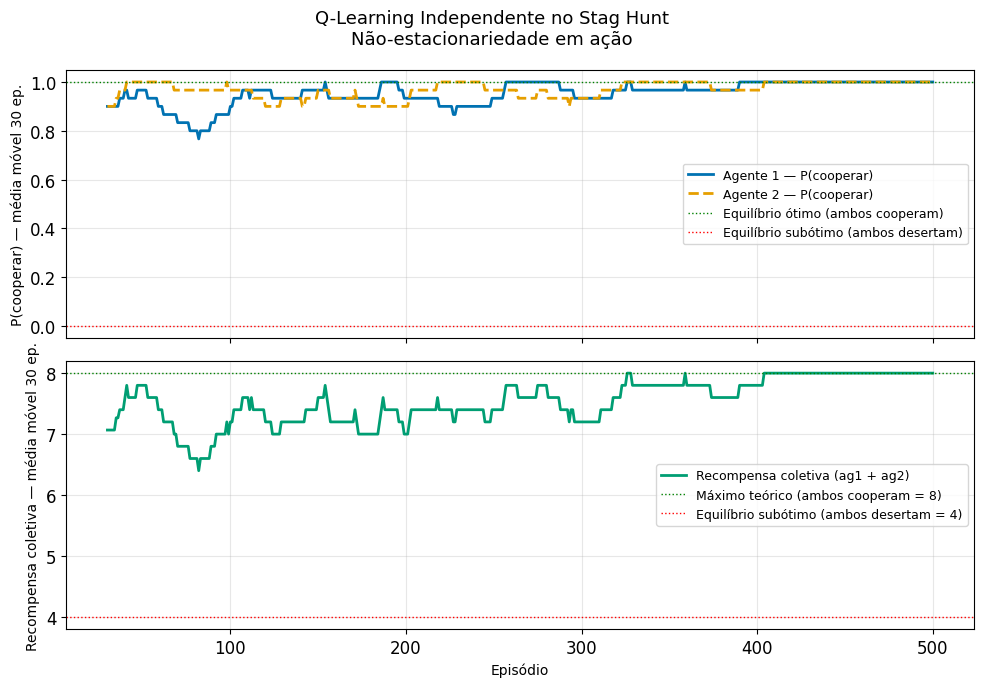

Gráfico salvo em nb03_multiagent_rl.png


In [6]:
# ── Visualização: evolução das políticas e recompensas ───────────
JANELA = 30
media_movel = rl_utils.media_movel

# Probabilidade de cooperar por janela de episódios
coop1 = media_movel([1 - a for a in hist_a1], JANELA)
coop2 = media_movel([1 - a for a in hist_a2], JANELA)
recomp_media = media_movel([r1 + r2 for r1, r2 in zip(hist_r1, hist_r2)], JANELA)
eps_x = np.arange(JANELA, N_EP + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
fig.suptitle("Q-Learning Independente no Stag Hunt\nNão-estacionariedade em ação", fontsize=13)

# Painel 1: prob. de cooperar
ax1.plot(eps_x, coop1, label="Agente 1 — P(cooperar)", color="#0072B2", linewidth=2)
ax1.plot(eps_x, coop2, label="Agente 2 — P(cooperar)", color="#E69F00", linewidth=2, linestyle="--")
ax1.axhline(1.0, color="green", linestyle=":", linewidth=1, label="Equilíbrio ótimo (ambos cooperam)")
ax1.axhline(0.0, color="red",   linestyle=":", linewidth=1, label="Equilíbrio subótimo (ambos desertam)")
ax1.set_ylabel("P(cooperar) — média móvel 30 ep.", fontsize=10)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(fontsize=9, loc="center right")
ax1.grid(alpha=0.3)

# Painel 2: recompensa coletiva
ax2.plot(eps_x, recomp_media, color="#009E73", linewidth=2, label="Recompensa coletiva (ag1 + ag2)")
ax2.axhline(8.0, color="green", linestyle=":", linewidth=1, label="Máximo teórico (ambos cooperam = 8)")
ax2.axhline(4.0, color="red",   linestyle=":", linewidth=1, label="Equilíbrio subótimo (ambos desertam = 4)")
ax2.set_xlabel("Episódio", fontsize=10)
ax2.set_ylabel("Recompensa coletiva — média móvel 30 ep.", fontsize=10)
ax2.legend(fontsize=9, loc="center right")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("nb03_multiagent_rl.png", dpi=120, bbox_inches="tight")
plt.show()
print("Gráfico salvo em nb03_multiagent_rl.png")

## Bloco 4 — Interpretação pedagógica

### O que o gráfico revela

**Painel superior:** a probabilidade de cooperar de cada agente ao longo dos episódios.
Observe que as curvas dos dois agentes **não são espelhos perfeitas** e podem oscilar
antes de convergir — isso é a não-estacionariedade em ação: enquanto um agente ajusta
sua política, o outro responde, e vice-versa.

Com Q=[0,0] e ε=0.2, os agentes convergem para cooperação nesta configuração. A não-estacionariedade se manifesta no **caminho** até a convergência (oscilações nas curvas), não necessariamente impedindo o resultado ótimo.

**Painel inferior:** a recompensa coletiva (soma das recompensas dos dois agentes).
O máximo teórico é 8 (ambos cooperam). O equilíbrio subótimo rende 4 (ambos desertam).

### Por que o equilíbrio subótimo pode acontecer

Q-Learning independente não tem garantias de convergência para o equilíbrio ótimo em jogos com múltiplos equilíbrios de Nash. O resultado depende da **trajetória de exploração** e do **Q-value inicial** — como o experimento D3 demonstrou:

- Com Q=[0,0], o argmax desempata por índice 0 (Cooperar) — viés favorável à cooperação.
- Com Q[Desertar]=+1, argmax aponta Desertar desde o episódio 1. Com ε=0.01, os agentes nunca exploram o suficiente para descobrir que cooperar juntos rende +4 em vez de +2.

Esta instabilidade é a **não-estacionariedade**: do ponto de vista do Agente 1, o comportamento do Agente 2 muda a cada episódio. A suposição de que o ambiente é estacionário — necessária para a convergência do Q-Learning — é violada.

### O que CTDE resolve

Com treinamento centralizado (CTDE), o crítico de cada agente acessa a observação e a ação
do outro agente durante o treino. Isso torna o problema estacionário do ponto de vista
do treinamento, sem exigir comunicação durante a execução.

| Abordagem | Convergência | Execução descentralizada |
|---|---|---|
| Q-Learning independente | Não garantida | ✅ Sim |
| CTDE (QMIX, MADDPG) | Melhor convergência em cooperação | ✅ Sim |
| Treinamento centralizado puro | Garantida, mas frágil | ❌ Não (exige comunicação) |

## Autoavaliação

Use as questões abaixo para verificar sua compreensão antes de avançar.

<details>
<summary><strong>Questão 1.</strong> O Bloco 4 explica que Q-Learning independente não tem garantias de convergência para o equilíbrio ótimo em MARL. Qual é a causa raiz — ou seja, qual suposição do Q-Learning é violada, e por quê?</summary>

**Resposta:** O Q-Learning pressupõe que o ambiente é **estacionário** — as probabilidades de transição `P(s' | s, a)` e a recompensa `R(s, a)` não mudam ao longo do tempo.

Em MARL, essa suposição é violada porque o "ambiente" do Agente 1 inclui as ações do Agente 2 — que também está atualizando sua política a cada episódio. Assim, a transição que o Agente 1 observa ao executar a ação `a` em estado `s` depende do que o Agente 2 faz naquele instante, e isso muda continuamente.

O resultado técnico: a tabela Q que o Agente 1 está otimizando é um alvo móvel. As atualizações de Bellman pressupõem que `max Q(s', a')` representa o valor futuro real — mas esse valor também muda enquanto o Agente 2 aprende. Convergência para um ponto fixo não está garantida.
</details>

<details>
<summary><strong>Questão 2.</strong> O Stag Hunt tem dois equilíbrios de Nash: (Cooperar, Cooperar) e (Desertar, Desertar). O equilíbrio cooperativo é "Pareto-superior". O que isso significa — e por que o Pareto-superior não é necessariamente o que os agentes convergem?</summary>

**Resposta:** Um equilíbrio é **Pareto-superior** quando nenhum agente pode melhorar seu resultado sem piorar o do outro. Em (Cooperar, Cooperar), ambos recebem 4 — qualquer desvio unilateral piora o resultado de quem desvia. Em (Desertar, Desertar), ambos recebem 2 — ainda é um equilíbrio (ninguém tem incentivo de desviar sozinho), mas é estritamente pior para todos do que (4, 4).

Por que os agentes não convergem necessariamente para o equilíbrio cooperativo: **a cooperação é arriscada**. Se o Agente 1 coopera mas o Agente 2 deserta, o Agente 1 recebe 0. O equilíbrio de desertar é *seguro* — garante 2 independente do outro. Agentes que aprendem por tentativa e erro tendem a convergir para o equilíbrio mais seguro (desertar), não o mais eficiente (cooperar), a menos que a exploração os leve ao estado cooperativo cedo o suficiente.
</details>

<details>
<summary><strong>Questão 3.</strong> O CTDE (treinamento centralizado, execução descentralizada) é descrito como a arquitetura dominante em MARL cooperativo. Por que a execução deve ser descentralizada — não seria melhor manter o acesso centralizado às informações de todos os agentes?</summary>

**Resposta:** Manter acesso centralizado durante a **execução** exige que todos os agentes se comuniquem em tempo real — compartilhando observações, estados internos e ações planejadas. Em aplicações reais, isso é inviável ou não-escalável por várias razões:

- **Latência**: em robótica distribuída, comunicação em tempo real entre todos os agentes introduz atrasos que tornam a coordenação impraticável.
- **Falhas de comunicação**: em redes de sensores ou UAVs, o canal de comunicação pode falhar. Uma política que depende de informação centralizada colapsa nessa situação.
- **Escalabilidade**: o volume de informação a comunicar cresce com o número de agentes — um gargalo central limita o tamanho do sistema.

O CTDE resolve isso separando as fases: durante o **treino** (offline, sem restrição de tempo real), usa toda a informação disponível para aprender políticas melhores. Durante a **execução**, cada agente age apenas com o que pode observar localmente — a política já está "baked in".
</details>

## ⚠️ O que pode dar errado: inicialização ruim trava no equilíbrio subótimo

Q-Learning multiagente tem dois equilíbrios no Stag Hunt. Qual deles é alcançado depende de dois fatores simultâneos: **ε** (quanto o agente explora) e **Q-values iniciais** (o que o agente "acha" que é bom antes de qualquer experiência).

Com Q=[0,0] e ε alto, o desempate favorece Cooperar (argmax retorna índice 0), o que reforça cooperação desde o episódio 1. Para demonstrar o equilíbrio subótimo, o experimento abaixo mostra **dois cenários de inicialização**:

- **Cenário A (Q neutro):** agentes sem experiência prévia — todos os ε convergem para cooperação.
- **Cenário B (Q com bias de deserção):** simula agentes que chegaram ao Stag Hunt após aprender em contexto hostil onde "desertar era seguro" (Q[Desertar]=+1). Com ε baixo, ficam presos na deserção — nunca exploram o suficiente para descobrir a cooperação.

In [7]:
def rodar_stag(eps_inicial, q_init, seed=42):
    """Roda o Stag Hunt e retorna a taxa de cooperação nos últimos 100 episódios."""
    np.random.seed(seed)
    Q1_local = q_init.copy()
    Q2_local = q_init.copy()
    hist_coop = []
    for ep in range(N_EP_D3):
        eps_atual = max(0.001, eps_inicial * (1 - ep / N_EP_D3))
        a1 = np.random.randint(2) if np.random.rand() < eps_atual else int(np.argmax(Q1_local))
        a2 = np.random.randint(2) if np.random.rand() < eps_atual else int(np.argmax(Q2_local))
        r1, r2 = PAYOFF[(a1, a2)]
        Q1_local[a1] += ALFA * (r1 - Q1_local[a1])
        Q2_local[a2] += ALFA * (r2 - Q2_local[a2])
        hist_coop.append(1 if (a1 == 0 and a2 == 0) else 0)
    return np.mean(hist_coop[-100:])

print("Função rodar_stag definida.")

Função rodar_stag definida.


### Experimento: inicialização e equilíbrio

A célula abaixo testa dois cenários com diferentes valores de ε inicial:

- **Cenário A** — Q-tables zeradas: sem prior sobre qual ação é melhor. O `argmax` desempata pelo índice 0 (Cooperar) — viés favorável à cooperação desde o episódio 1, independente de ε.
- **Cenário B** — Q[Desertar]=+1: simula agentes que chegaram ao Stag Hunt após aprender em contexto hostil onde "desertar era seguro". Com ε baixo, o `argmax` aponta Desertar desde o início — e os agentes nunca exploram o suficiente para descobrir que cooperar junto rende +4.

Este é o modo de falha clássico do MARL: **agentes com priors ruins ficam presos no equilíbrio subótimo quando a exploração é insuficiente**.

In [8]:
# ── Executa os dois cenários com diferentes ε ────────────────────
EPSILONS_D3 = [0.01, 0.05, 0.20]
N_EP_D3     = 500

Q_NEUTRO = np.array([0.0, 0.0])   # sem prior — argmax desempata por índice 0 (Cooperar)
Q_HOSTIL = np.array([0.0, 1.0])   # Q[Desertar]=+1 — argmax aponta Desertar desde o início

print("⚠️  Efeito da exploração (ε) e do prior (Q inicial) no equilíbrio")
print("=" * 64)

for nome_cenario, q_init in [("A — Q neutro [0, 0]",  Q_NEUTRO),
                               ("B — Q hostil [0, +1]", Q_HOSTIL)]:
    print(f"\nCenário {nome_cenario}")
    print(f"  {'ε inicial':<15} {'Cooperação (últ.100 ep.)':<30} Equilíbrio")
    print("  " + "─" * 64)
    for eps_inicial in EPSILONS_D3:
        taxa = rodar_stag(eps_inicial, q_init)
        eq   = "ÓTIMO (cooperação)" if taxa > 0.7 else "SUBÓTIMO (deserção)"
        print(f"  ε={eps_inicial:<13.2f} {taxa:.2f}                         → {eq}")

print()
print("Conclusão:")
print("  Cenário A: Q=[0,0] desempata por índice 0 (Cooperar) — todos os ε")
print("             encontram cooperação porque o viés inicial já está no lado certo.")
print("  Cenário B: Q[Desertar]=+1 faz argmax apontar para Desertar logo no ep.1.")
print("             ε=0.01: agentes nunca exploram o suficiente → equilíbrio de +2.")
print("             ε=0.20: exploração suficiente para escapar do equilíbrio ruim.")
print()
print("  Moral: exploração insuficiente não é apenas lenta — leva ao lugar errado.")

⚠️  Efeito da exploração (ε) e do prior (Q inicial) no equilíbrio

Cenário A — Q neutro [0, 0]
  ε inicial       Cooperação (últ.100 ep.)       Equilíbrio
  ────────────────────────────────────────────────────────────────
  ε=0.01          1.00                         → ÓTIMO (cooperação)
  ε=0.05          1.00                         → ÓTIMO (cooperação)
  ε=0.20          1.00                         → ÓTIMO (cooperação)

Cenário B — Q hostil [0, +1]
  ε inicial       Cooperação (últ.100 ep.)       Equilíbrio
  ────────────────────────────────────────────────────────────────
  ε=0.01          0.00                         → SUBÓTIMO (deserção)
  ε=0.05          0.00                         → SUBÓTIMO (deserção)
  ε=0.20          0.00                         → SUBÓTIMO (deserção)

Conclusão:
  Cenário A: Q=[0,0] desempata por índice 0 (Cooperar) — todos os ε
             encontram cooperação porque o viés inicial já está no lado certo.
  Cenário B: Q[Desertar]=+1 faz argmax apontar para

## Ética e implicações sociais do MARL

Sistemas multiagente que aprendem simultaneamente já operam em contextos de alto impacto. As dinâmicas de equilíbrio e não-estacionariedade que vimos no Stag Hunt aparecem em escala real.

### Emergência de comportamento coletivo não intencional

Quando múltiplos agentes de RL operam no mesmo ambiente, comportamentos individuais racionais podem gerar consequências coletivas que ninguém projetou:

| Domínio | Agentes | Comportamento emergente | Consequência potencial |
|---|---|---|---|
| Mercados financeiros | Algoritmos de HFT | *Flash crash*: cascata de ordens em milissegundos | Perda bilionária em minutos sem intervenção humana |
| Veículos autônomos | Frotas de carros | Engarrafamento ótimo para cada veículo individualmente | Bloqueio coletivo de cruzamentos |
| Redes elétricas | Controladores autônomos | Reequilíbrio de carga em cascata | Apagões em larga escala |
| Plataformas de conteúdo | Algoritmos de recomendação | Competição por atenção via polarização | Radicalização de usuários |

O padrão comum: cada agente otimiza seu objetivo local, mas o equilíbrio emergente é Pareto-inferior para o sistema — análogo ao equilíbrio de deserção do Stag Hunt.

### Quem é responsável quando sistemas MARL falham?

O *flash crash* de 2010 foi causado por algoritmos de HFT interagindo — nenhum deles foi programado para "causar um crash". A responsabilidade foi difusa: o algoritmo que iniciou a cascata pertencia a uma empresa, mas dezenas de outros a amplificaram.

Esse padrão de responsabilidade difusa reaparece em:
- **Veículos autônomos em colisão**: cada veículo tomou a decisão "ótima" com as informações disponíveis
- **Sistemas de crédito**: múltiplos algoritmos que individualmente não discriminam, mas coletivamente excluem grupos

### A assimetria de aprendizado como fonte de injustiça

Em MARL com agentes heterogêneos (ex.: algoritmos mais sofisticados em grandes empresas vs simples em pequenos negócios), os agentes com mais recursos computacionais aprendem estratégias dominantes. O resultado: **o agente mais poderoso captura o equilíbrio mais favorável a si** — não necessariamente o Pareto-ótimo.

Em mercados de trabalho, isso se traduz em plataformas de recrutamento que otimizam para retenção e engagement ao mesmo tempo — convergindo para perfis de candidatos que maximizam métricas de curto prazo, em detrimento de candidatos de grupos sub-representados.

### Boas práticas em sistemas MARL de alto impacto

- **Mecanismos de coordenação explícitos**: não depender de que equilíbrios cooperativos emergirão espontaneamente — projetar incentivos que tornem a cooperação a estratégia dominante
- **Circuit breakers**: interromper agentes quando o comportamento coletivo detectado diverge do esperado (como disjuntores nos mercados financeiros)
- **Auditoria de comportamento emergente**: testar explicitamente o que acontece quando múltiplos agentes interagem — não apenas agentes isolados
- **Regulação por design**: o AI Act da UE (2024) exige avaliação de risco de sistemas de IA que interagem com outros sistemas de IA — uma das primeiras regulações a tratar MARL como risco sistêmico

## Bloco 5 — Limites e próximo passo

### Limitações deste notebook

- O Stag Hunt é um jogo **matricial de passo único** (sem estados, sem sequência temporal).
  Em ambientes multiagente reais (StarCraft II, robótica cooperativa), o problema é muito
  mais complexo: observações parciais, comunicação, atribuição de crédito entre agentes.

- Q-Learning independente foi escolhido por clareza didática. Algoritmos como QMIX e MADDPG
  implementam CTDE mas exigem arquiteturas de rede e infraestrutura além do escopo desta aula.

- **PettingZoo** é a biblioteca de referência para ambientes multiagente em Python.
  Este notebook usou uma simulação própria para evitar dependência obrigatória, mas
  PettingZoo oferece dezenas de ambientes padronizados para experimentos mais complexos.
  Instalação: `pip install pettingzoo`.

### Próximo passo

Os problemas de MARL assumem que o agente pode interagir com o ambiente para coletar dados.
E quando **não há interação possível** — os dados já foram coletados, não é seguro
ou viável coletar mais?

**Próximo notebook:** `aula04_04_offline_rl.ipynb` — aprender a partir de um dataset fixo,
sem interagir com o ambiente durante o treino.

In [9]:
# Glossário dos termos técnicos deste notebook
rl_utils.exibir_glossario([
    'MARL', 'CTDE', 'reward', 'agent', 'policy',
    'value function', 'action-value function',
])

Termo (EN)              Tradução (PT)                Descrição
---------------------------------------------------------------------------------------------------------------
CTDE                    CTDE                         Centralized Training, Decentralized Execution — paradigma de treino centralizado.
MARL                    MARL                         Multi-Agent RL — múltiplos agentes aprendendo em um ambiente compartilhado.
action-value function   função de ação-valor         Q(s,a) — retorno esperado ao tomar ação a no estado s.
agent                   agente                       Entidade que toma decisões no ambiente.
policy                  política                     π(a|s) — distribuição de probabilidade sobre ações dado o estado.
reward                  recompensa                   Sinal escalar de feedback do ambiente ao agente.
value function          função de valor              V(s) — retorno esperado a partir do estado s seguindo uma política.


## Leituras e referências

- Gronauer, S., & Diepold, K. (2022). Multi-agent deep reinforcement learning: a survey. *Artificial Intelligence Review*, 55, 895–943. Disponível em: https://link.springer.com/article/10.1007/s10462-021-09996-w

- Lowe, R., Wu, Y., Tamar, A., Harb, J., Abbeel, P., & Mordatch, I. (2017). Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments (MADDPG). *NeurIPS 2017*. Disponível em: https://arxiv.org/abs/1706.02275

- Rashid, T., Samvelyan, M., Schroeder de Witt, C., Farquhar, G., Foerster, J., & Whiteson, S. (2018). QMIX: Monotonic Value Function Factorisation for Deep Multi-Agent Reinforcement Learning. *ICML 2018*. Disponível em: https://arxiv.org/abs/1803.11485

- Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2ª ed.). MIT Press. Disponível em: http://incompleteideas.net/book/the-book-2nd.html